In [ ]:
#import relevant libraries
import os
#from scipy import stats

import numpy as np
#import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap


import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#NOTE: SUPPRESSES WARNINGS!

import warnings


warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)


In [ ]:
#initial file processing
workcomp = "C:\\Users\\User"
computer2 = "C:\\Users\\lnico"
officecomp = "C:\\Users\\Star"
homecomp = "D:"
filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\"
titledpath = homecomp
openPath = titledpath + filedir
files = os.listdir(openPath)

#identifying genotypes
responder = "ACR"
respondercsv = responder + ".csv"
wt = "w1118"


In [ ]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = [titledpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

[f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Fira Mono"

In [ ]:
lstnew=[]


for file_no in os.listdir(openPath): 
    if respondercsv in file_no and "w1118" not in file_no :   #wt > acr files
        f = os.path.join(openPath, file_no)
        dfe=pd.read_csv(f)
        exptdf = dfe.drop(dfe.columns[[0]],axis = 1)
        driver = file_no.split(" ")[0]
        lstnew.append(driver)

## Code

## Combined files

In [ ]:
newfile2 = openPath + "Compilation with delta\\2025meandiffcollection\\"
files2 = os.listdir(newfile2)
totalfile = pd.DataFrame()

for n in files2:
    
    openfile = pd.read_csv(newfile2 + n)
    nameofmbon = n.split(" ")[0] 
    openfile['responder'] = n.split(" ")[2]
    totalfile = pd.concat([totalfile, openfile], axis = 0).reset_index(drop=True)

lstofallvariables = []
for n in totalfile.columns.to_list()[1:-1]:
    lstofallvariables.append(n.split("_")[0])
lstnamings= list(set(lstofallvariables))

totalfile['genotypeandresponder'] = totalfile["MBON"] + "_" + totalfile['responder']   #has bootstraps


In [ ]:
#only delta-g
onlymeans = totalfile.loc[:, ~totalfile.columns.str.endswith('_bootstrap')].drop_duplicates().reset_index(drop=True)
onlymeans

## Lin Reg via metrics (not updated)

In [ ]:
dfreg_a = matchingdfs(dfreg_ACR, matchingset)
dfreg_c = matchingdfs(dfreg_Cr2, matchingset)

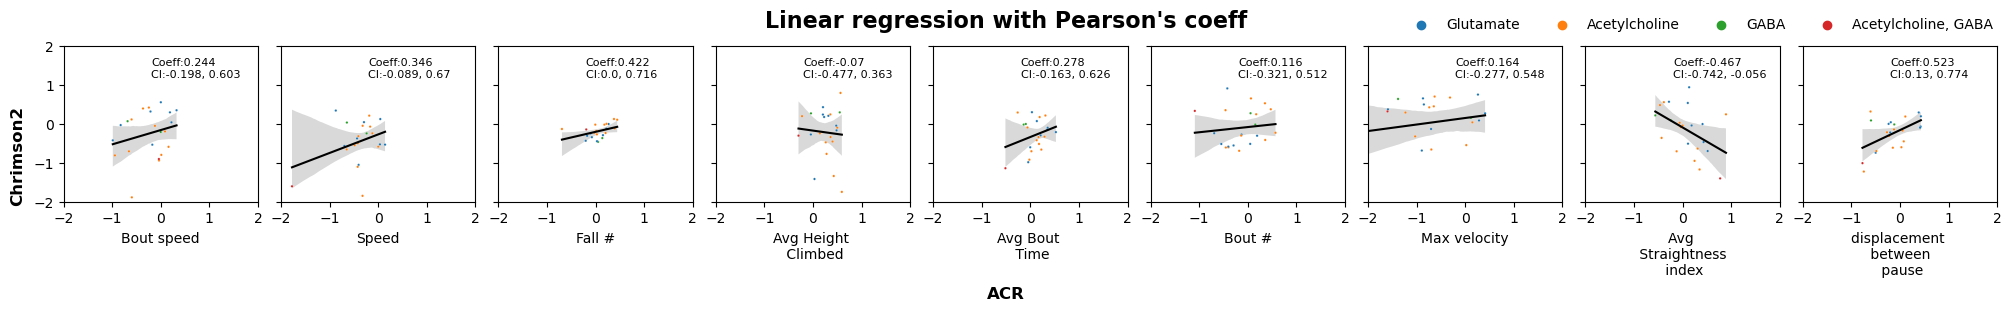

In [ ]:
import scipy.stats
fig2, ax2 = plt.subplots(nrows = 1, ncols = 9, figsize = (20, 3), sharey = True, layout= 'constrained')
labels = [ ' \n '.join(wrap(l, 12)) for l in dfreg_a.columns[:-2].tolist()]

for c,(n,leg) in enumerate(zip(dfreg_a.columns[:-2].tolist(),8*[False]+[True])):
    spare = pd.DataFrame()
    spare["ACR"] = matchinglobesets(dfreg_a, lobelocation)[n]
    spare['Chrimson2'] = matchinglobesets(dfreg_c, lobelocation)[n]
    spare['NT'] = matchinglobesets(dfreg_c, lobelocation)['Neurotransmitter']
    sns.regplot(x="ACR", y="Chrimson2", data=spare, ci = 95, scatter = False, line_kws={"color": "black", 'lw': 1.5}, ax=ax2[c]) 
    sns.scatterplot(x="ACR", y="Chrimson2", data=spare, hue='NT', s = 3, ax = ax2[c], legend = leg)
    ax2[c].set_xlim([-2,2])
    ax2[c].set_ylim([-2,2])
    ax2[c].set_xlabel(labels[c])
    ax2[c].set_ylabel("")
    
    #pearsons correlation
    pearsonscorrelation = scipy.stats.pearsonr(dfreg_a[n], dfreg_c[n]) #correlation instead of linear regression: trying to find the relationship rather than causation    
    civallow = pearsonscorrelation.confidence_interval(confidence_level=0.95)[0] 
    civalhigh = pearsonscorrelation.confidence_interval(confidence_level=0.95)[1]   
    ax2[c].annotate("Coeff:" + str(round(pearsonscorrelation[0],3)) + "\nCI:" + str(round(civallow,3)) + ", " + str(round(civalhigh,3)), (0.45, 0.8), ha = "left", xycoords = 'axes fraction', fontsize = 8)

fig2.supxlabel("ACR", weight = "bold")
fig2.supylabel("Chrimson2", weight = "bold")
fig2.suptitle("Linear regression with Pearson's coeff", fontsize = 16, weight="bold")

new_labels = ['Glutamate', 'Acetylcholine', 'GABA', 'Acetylcholine, GABA']
legend_handles, _= ax2[c].get_legend_handles_labels()
lgd = fig2.legend(legend_handles, new_labels, 
          bbox_to_anchor=(1,1), ncol = 4, frameon = False)
ax2[c].get_legend().set_visible(False)

#plt.savefig(openPath + "images\\" + date + "_" + responder + "_bidirectionalitycheck.png", dpi = 1200, bbox_inches='tight')

## Lin regression grouped by circles (not updated)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.cluster import SpectralClustering
from matplotlib.patches import Ellipse
# fig3, axthree = plt.subplots(nrows = 1, ncols = 9, figsize = (20, 3), sharey = True, layout= 'constrained')


for c,(n,leg) in enumerate(zip(dfreg_a.columns[:-2].tolist(),8*[False]+[True])):
    fig3, axthree = plt.subplots(figsize = (4, 4))
    
    spare = pd.DataFrame()
    spare["ACR"] = matchinglobesets(dfreg_a, lobelocation)[n]
    spare['Chrimson2'] = matchinglobesets(dfreg_c, lobelocation)[n]
    spare['NT'] = matchinglobesets(dfreg_c, lobelocation)['Neurotransmitter']
    
    #kmeans
    kmeans = SpectralClustering(n_clusters=3)
    clusters = kmeans.fit_predict(spare.iloc[:,0:2])
    cluster = ['k-means_c_' + str(c) for c in clusters]
    X = spare.iloc[:,0:2]
    ogdots = ['#d90429','#f7b267', '#89fc00', '#735751'] #neurotransmitters : red, orange, green, brown
    clusterdots = ["#03045e", '#0077b6', "#00b4d8", "#90e0ef"] #clustering patterns :blue
    
    #neto = sns.scatterplot(x="ACR", y="Chrimson2", data=spare, hue='NT', s = 80, edgecolor = "none", palette = ogdots , legend = True)
    sns.scatterplot(x="ACR", y="Chrimson2", data=X.iloc[:,0:2].assign(cluster = cluster), hue='cluster', palette = clusterdots, legend = False, s = 40, edgecolor = "none")
           
    axthree.set_xlim([-2,2])
    axthree.set_ylim([-2,2])
    axthree.set_xlabel("")
    axthree.set_ylabel("")
    plt.yticks(fontsize=6)
    plt.xticks(fontsize=6)
    

    fig3.supxlabel("ACR", fontsize = 8,  weight = "bold")
    fig3.supylabel("Chrimson2", fontsize = 8, weight = "bold")
    fig3.suptitle(n, fontsize = 12, weight="bold")
    plt.legend(loc=2, prop={'size': 8})
#plt.savefig(openPath + "images\\" + date + "_" + responder + "_bidirectionalitycheck.png", dpi = 1200, bbox_inches='tight')

In [ ]:
df_completeresponder = pd.concat([dfreg_a, dfreg_c])
df_lregmbon = df_completeresponder.sort_values(['MBON']).reset_index(drop=True)

In [ ]:
import scipy.stats
fig7, ax7 = plt.subplots(nrows = 5, ncols = 5, figsize = (10, 10), sharey = True, sharex = True, layout= 'constrained')
for name,row,col in zip(dfreg_a['MBON'], 5*list(range(0,5)), 5*[0]+5*[1]+5*[2]+5*[3]+ 5*[4] +5*[5]):
    df_meltedreg = pd.melt(df_lregmbon[(df_lregmbon['MBON'] == name)], id_vars = ['responder', "MBON"])   
    df_a1= df_meltedreg[(df_meltedreg['responder'] == 'Cr2')]
    df_c1=df_meltedreg[(df_meltedreg['responder'] == 'ACR')]
    
    ax7[row][col].scatter(x= df_a1['value'], y = df_c1['value'],
                color='grey',
                edgecolors="r",
                alpha=0.8,
                s=30)
    
    sns.regplot(x= df_a1['value'], y = df_c1['value'],
                scatter=False,
                line_kws={'lw':1}, 
                color="k",
                ax=ax7[row][col],
                truncate=False)

    ax7[row][col].set(xlabel=None)
    ax7[row][col].set(ylabel=None)
    ax7[row][col].set_ylim(-2.1,2.1)  
    ax7[row][col].set_xlim(-2.1,2.1) 
    ax7[row][col].set_title(name, fontsize = 12)

    
    #pearsons correlation
    pearsonscorrelation = scipy.stats.pearsonr(df_a1['value'], df_c1['value']) #correlation instead of linear regression: trying to find the relationship rather than causation    
    civallow = pearsonscorrelation.confidence_interval(confidence_level=0.95)[0] 
    civalhigh = pearsonscorrelation.confidence_interval(confidence_level=0.95)[1]
    ax7[row][col].annotate("Coeff:" + str(round(pearsonscorrelation[0],3)) + "\nCI:" + str(round(civallow,3)) + ", " + str(round(civalhigh,3)), (0.55, 0.8), ha = "left", xycoords = 'axes fraction', fontsize = 9)

    
fig7.supxlabel("ACR", weight = "bold")
fig7.supylabel("Chrimson2", weight = "bold")
fig7.suptitle("Linear regression with Pearson's coeff", fontsize = 16, weight="bold")

#plt.savefig(openPath + "images\\" + date + "_" + responder + "_bidirectionalitycheckMBON.png", dpi = 1200, bbox_inches='tight')